# **Notebook 5**

#### Ian García
#### A01706892


Fuente: https://aire.cdmx.gob.mx → Datos → Contaminante  
Periodo: 2024, 2025, 2026 (`Contaminantes_2024_2026.csv`)

**0. Configuración**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

CSV = "Contaminantes_2024_2026.csv"  # ajustar ruta si es necesario

**1. Ingesta**

In [16]:
df = pd.read_csv(CSV)
print(df.shape)
df.head()

(5394153, 5)


,date,id_station,id_parameter,value,unit
0,2024-01-01 01:00:00,ACO,CO,NaN,15.0
1,2024-01-01 01:00:00,ACO,NO,NaN,1.0
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.0
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.0
4,2024-01-01 01:00:00,ACO,O3,NaN,1.0


In [17]:
df.info()
df["id_parameter"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 5394153 entries, 0 to 5394152
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          str    
 1   id_station    str    
 2   id_parameter  str    
 3   value         float64
 4   unit          float64
dtypes: float64(2), str(3)
memory usage: 205.8 MB


id_parameter
O3       661850
NO2      661106
NO       650195
NOX      649451
CO       629021
SO2      626789
PM10     569906
PM2.5    513806
PMCO     432029
Name: count, dtype: int64

**2. Limpieza**

In [18]:
df["date"] = pd.to_datetime(df["date"], format="mixed")

print("nulos en value:", df["value"].isna().mean().round(4))

df = df.dropna(subset=["value"])
df = df[df["value"] >= 0]
df = df.drop_duplicates(subset=["date", "id_station", "id_parameter"])

print(df.shape)
print(df["date"].min(), "→", df["date"].max())

nulos en value: 0.4371
(3036236, 5)
2024-01-01 01:00:00 → 2026-02-28 23:00:00


Unidades

In [19]:
cod_por_param = df.dropna(subset=["unit"]).groupby("id_parameter")["unit"].first()
df["unit"] = df["unit"].fillna(df["id_parameter"].map(cod_por_param)).astype(int)

UNIDADES = {1: "ppb", 2: "µg/m³", 15: "ppm"}
df["unidad"] = df["unit"].map(UNIDADES)

df[["id_parameter", "unit", "unidad"]].drop_duplicates().sort_values("id_parameter")

,id_parameter,unit,unidad
7,CO,15,ppm
8,NO,1,ppb
9,NO2,1,ppb
10,NOX,1,ppb
11,O3,1,ppb
12,PM10,2,µg/m³
13,PM2.5,2,µg/m³
14,PMCO,2,µg/m³
15,SO2,1,ppb


**3. Feature engineering**

In [20]:
df["anio"] = df["date"].dt.year
df["mes"] = df["date"].dt.month
df["hora"] = df["date"].dt.hour
df["dia_semana"] = df["date"].dt.dayofweek          # 0 = lunes
df["fin_de_semana"] = df["dia_semana"] >= 5

df.head()

,date,id_station,id_parameter,value,unit,unidad,anio,mes,hora,dia_semana,fin_de_semana
7,2024-01-01 01:00:00,AJM,CO,0.23,15,ppm,2024,1,1,0,False
8,2024-01-01 01:00:00,AJM,NO,0.00,1,ppb,2024,1,1,0,False
9,2024-01-01 01:00:00,AJM,NO2,10.00,1,ppb,2024,1,1,0,False
10,2024-01-01 01:00:00,AJM,NOX,10.00,1,ppb,2024,1,1,0,False
11,2024-01-01 01:00:00,AJM,O3,43.00,1,ppb,2024,1,1,0,False


In [21]:
# Registros por año (2026 sólo cubre parte del año)
df.groupby("anio").size().rename("registros")

anio
2024    1402125
2025    1425789
2026     208322
Name: registros, dtype: int64

**4. Medidas de tendencia central**

In [22]:
def moda(s):
    m = s.round(1).mode()
    return m.iloc[0] if len(m) else np.nan

central = df.groupby("id_parameter")["value"].agg(
    n="count", media="mean", mediana="median", moda=moda
).round(3)
central["unidad"] = df.groupby("id_parameter")["unidad"].first()
central

,n,media,mediana,moda,unidad
id_parameter,,,,,
CO,408175,0.519,0.41,0.2,ppm
NO,351908,13.130,3.00,1.0,ppb
NO2,400657,23.177,21.00,14.0,ppb
NOX,351602,36.672,26.00,14.0,ppb
O3,475535,32.410,25.00,2.0,ppb
PM10,273971,41.822,36.00,26.0,µg/m³
PM2.5,227104,20.412,18.00,13.0,µg/m³
PMCO,147210,17.898,15.00,7.0,µg/m³
SO2,400074,3.002,1.00,1.0,ppb


In [23]:
# Desglose por año
central_anio = df.groupby(["id_parameter", "anio"])["value"].agg(
    media="mean", mediana="median", moda=moda
).round(3)
central_anio

media  mediana  moda
id_parameter anio                       
CO           2024   0.474     0.36   0.2
             2025   0.524     0.44   0.4
             2026   0.789     0.64   0.4
NO           2024  13.619     3.00   1.0
             2025  11.575     3.00   1.0
             2026  20.405     4.00   1.0
NO2          2024  23.513    21.00  14.0
             2025  21.957    20.00  15.0
             2026  29.539    27.00  25.0
NOX          2024  37.191    25.00  14.0
             2025  34.221    25.00  14.0
             2026  49.764    33.00  22.0
O3           2024  32.431    25.00   1.0
             2025  32.510    25.00   2.0
             2026  31.579    23.00   3.0
PM10         2024  43.299    38.00  26.0
             2025  38.853    34.00  23.0
             2026  52.091    46.00  37.0
PM2.5        2024  20.423    18.00  13.0
             2025  19.630    18.00  13.0
             2026  25.612    23.00  22.0
PMCO         2024  19.349    16.00   6.0
             2025  16.024    13.00   7.0
             2026  19.947    16.00   7.0
SO2          2024   2.574     1.00   1.0
             2025   2.819     1.00   1.0
             2026   7.004     3.00   2.0

**5. Medidas de dispersión**

In [24]:
disp = df.groupby("id_parameter")["value"].agg(
    varianza=lambda s: s.var(ddof=1),
    desv_est=lambda s: s.std(ddof=1),
    minimo="min",
    maximo="max",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
).round(3)
disp["rango"] = disp["maximo"] - disp["minimo"]
disp["iqr"] = disp["q3"] - disp["q1"]
disp["cv_%"] = (disp["desv_est"] / central["media"] * 100).round(2)
disp

,varianza,desv_est,minimo,maximo,q1,q3,rango,iqr,cv_%
id_parameter,,,,,,,,,
CO,0.173,0.416,0.0,6.09,0.25,0.66,6.09,0.41,80.15
NO,741.912,27.238,0.0,525.00,1.00,12.00,525.00,11.00,207.45
NO2,186.224,13.646,0.0,140.00,13.00,31.00,140.00,18.00,58.88
NOX,1281.228,35.794,0.0,575.00,15.00,44.00,575.00,29.00,97.61
O3,791.815,28.139,0.0,187.00,9.00,49.00,187.00,40.00,86.82
PM10,779.313,27.916,0.0,652.00,23.00,54.00,652.00,31.00,66.75
PM2.5,168.398,12.977,0.0,324.00,11.00,27.00,324.00,16.00,63.58
PMCO,203.822,14.277,0.0,304.00,8.00,24.00,304.00,16.00,79.77
SO2,34.045,5.835,0.0,247.00,1.00,3.00,247.00,2.00,194.37


In [25]:
# Desglose por año
df.groupby(["id_parameter", "anio"])["value"].agg(
    varianza=lambda s: s.var(ddof=1),
    desv_est=lambda s: s.std(ddof=1),
).round(3)

varianza  desv_est
id_parameter anio                    
CO           2024     0.171     0.414
             2025     0.145     0.381
             2026     0.310     0.557
NO           2024   814.528    28.540
             2025   557.968    23.621
             2026  1436.679    37.904
NO2          2024   194.692    13.953
             2025   160.486    12.668
             2026   259.322    16.103
NOX          2024  1395.986    37.363
             2025   994.385    31.534
             2026  2250.228    47.437
O3           2024   789.942    28.106
             2025   784.402    28.007
             2026   854.623    29.234
PM10         2024   817.831    28.598
             2025   667.186    25.830
             2026  1100.082    33.167
PM2.5        2024   174.321    13.203
             2025   138.494    11.768
             2026   294.856    17.171
PMCO         2024   211.750    14.552
             2025   185.678    13.626
             2026   224.966    14.999
SO2          2024    23.188     4.815
             2025    27.221     5.217
             2026   132.455    11.509

**6. Gráficas de distribución**

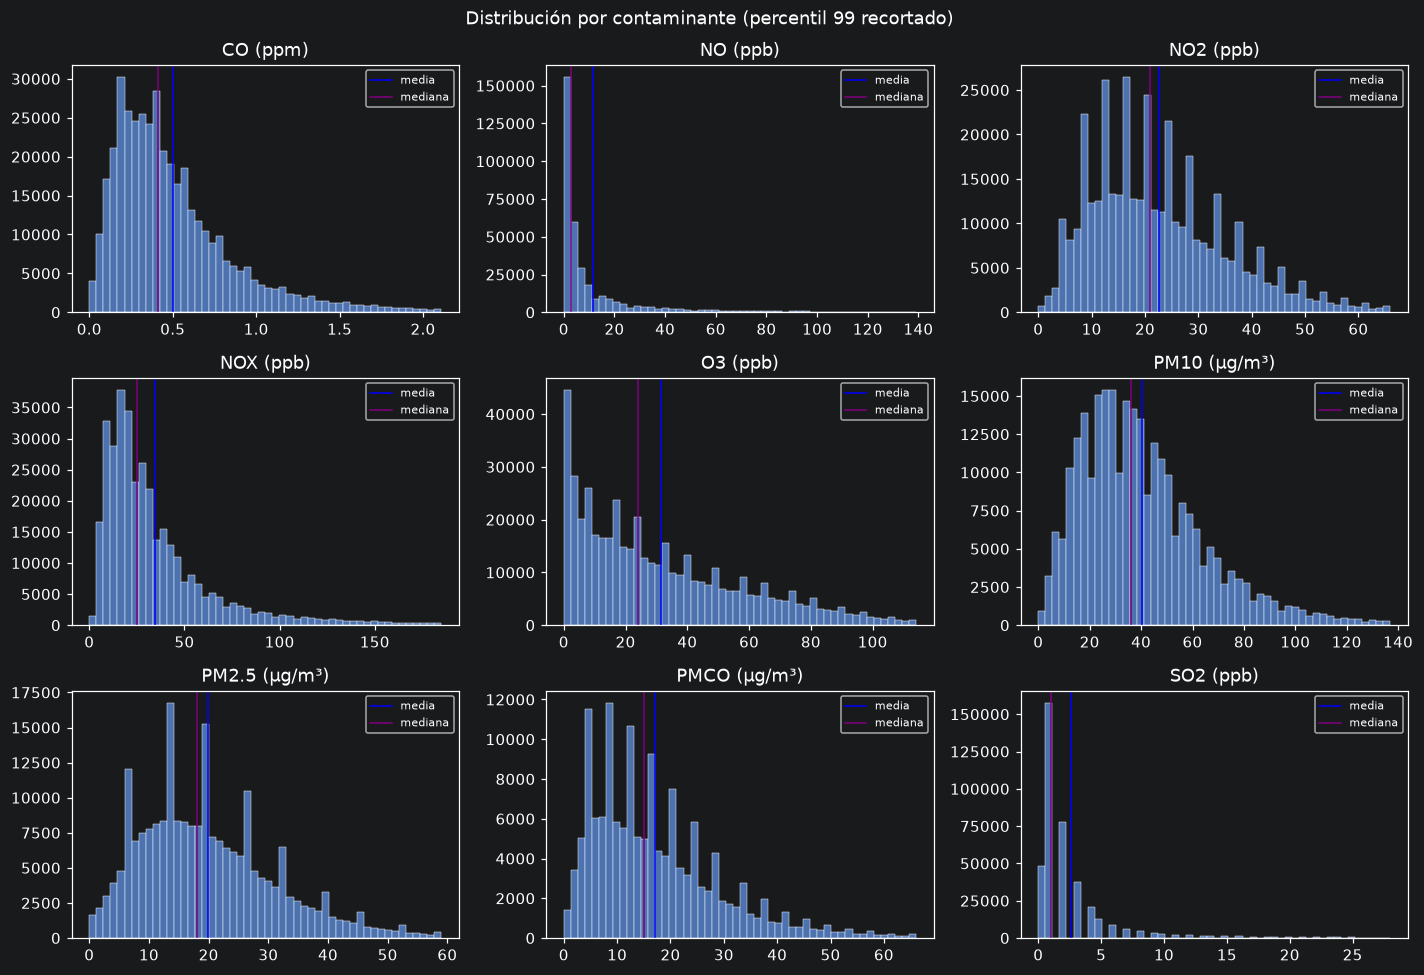

In [26]:
params = sorted(df["id_parameter"].unique())

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, p in zip(axes.ravel(), params):
    s = df.loc[df["id_parameter"] == p, "value"]
    s = s[s <= s.quantile(0.99)]          # recorte del 1% superior para visualizar la masa central
    ax.hist(s, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.axvline(s.mean(), color="blue", lw=1, label="media")
    ax.axvline(s.median(), color="purple", lw=1, label="mediana")
    ax.set_title(f'{p} ({central.loc[p, "unidad"]})')
    ax.legend(fontsize=7)
fig.suptitle("Distribución por contaminante (percentil 99 recortado)")
fig.tight_layout()
plt.show()

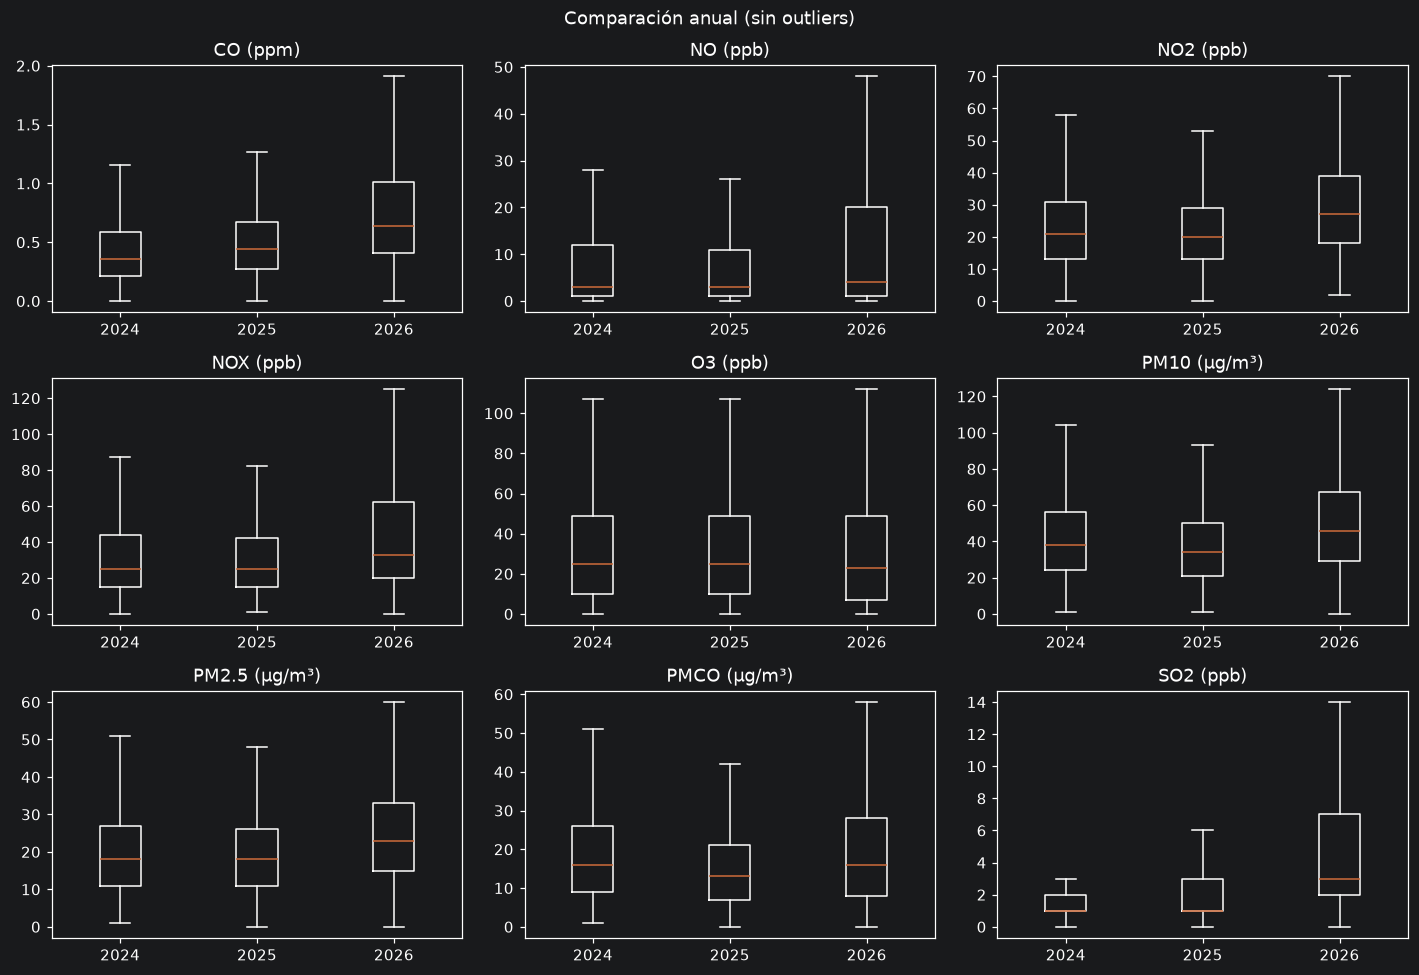

In [27]:
# Boxplot por año
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, p in zip(axes.ravel(), params):
    sub = df[df["id_parameter"] == p]
    datos = [sub.loc[sub["anio"] == a, "value"].values for a in sorted(sub["anio"].unique())]
    ax.boxplot(datos, showfliers=False)
    ax.set_xticklabels(sorted(sub["anio"].unique()))
    ax.set_title(f'{p} ({central.loc[p, "unidad"]})')
fig.suptitle("Comparación anual (sin outliers)")
fig.tight_layout()
plt.show()

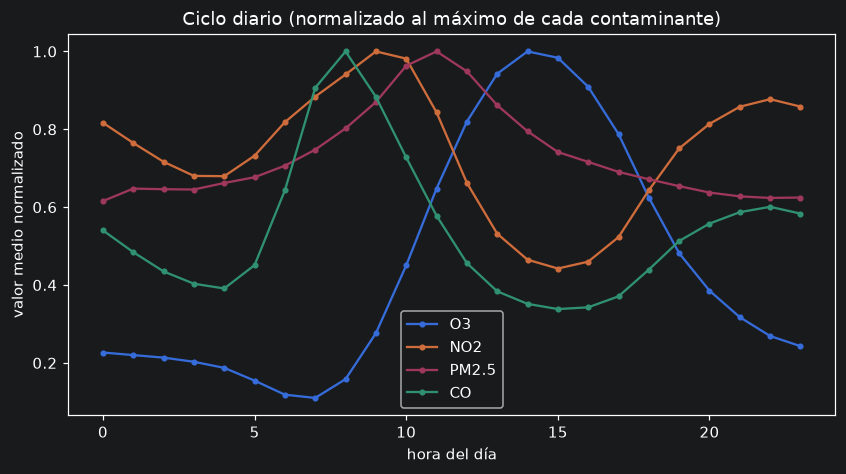

In [28]:
# Perfil horario promedio
fig, ax = plt.subplots(figsize=(9, 4.5))
for p in ["O3", "NO2", "PM2.5", "CO"]:
    serie = df[df["id_parameter"] == p].groupby("hora")["value"].mean()
    ax.plot(serie.index, serie / serie.max(), marker="o", ms=3, label=p)
ax.set_xlabel("hora del día")
ax.set_ylabel("valor medio normalizado")
ax.legend()
ax.set_title("Ciclo diario (normalizado al máximo de cada contaminante)")
plt.show()

**7. Observaciones**

- Todos los contaminantes presentan **asimetría positiva** (media > mediana > moda) con cola derecha larga: episodios de contaminación puntuales.
- Mayor dispersión relativa en `NO` (CV ≈ 208%) y `SO2` (CV ≈ 194%); la menor en `NO2` (CV ≈ 59%).
- `O3` alcanza su máximo diario alrededor de las 14 h (origen fotoquímico), mientras que `CO` y `NO2` lo hacen entre las 8 y 9 h (hora pico vehicular).
- 2026 sólo cubre enero y febrero, por lo que sus estadísticos anuales no son comparables directamente con 2024 y 2025 (sesgo estacional de invierno).